# **Notebook for data pre-processing and cleanning**


### Imports

In [1]:
import geopandas as gpd
import osmnx as ox
import numpy as np
import networkx as nx
import pandas as pd
from shapely.ops import unary_union
import contextily as cx
import matplotlib.pyplot as plt
from tqdm import tqdm
import h3
import pandana

%matplotlib inline
ox.__version__

'1.9.4'

# Data Loading

https://www.eng.klimadatastyrelsen.dk/mapping/geodesy-and-coordinate-systems

Based on that information, we will be using EPSG:25832 

In [2]:
#CRS_2 = "EPSG:25832"
CRS = "EPSG:4326"

## Boundaries from OSM

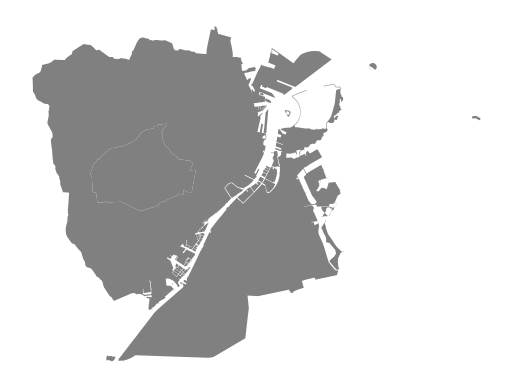

In [155]:
city = ox.geocode_to_gdf(["Copenhagen Municipality", "Frederiksberg Municipality"], by_osmid=False)
city_proj = ox.project_gdf(city)
ax = city_proj.plot(fc="gray", ec="none")
ax.axis("off");

## Addresses data

This data was extracted from: dataforsyningen.dk

The documentation is availible at: https://dawadocs.dataforsyningen.dk/dok/api/adresse#databeskrivelse

To download type in your browser: https://api.dataforsyningen.dk/adresser?kommunekode=0147&format=csv  (for copen kommunekode=0101)


In [72]:
# PATH_0147 = "../data/adresser_0147.csv"
# df_address_0147 = gpd.read_file(PATH_0147)
# print(f"Shape of df_address_0147: {df_address_0147.shape}")

In [73]:
PATH_0101 = "../data/adresser_0101.csv"
PATH_01010147 = "../data/adresser_0101_0147.csv"

# df_address_copen = gpd.read_file(PATH_0101)
# print(f"Shape of df_address_copen: {df_address_copen.shape}")
df_address = gpd.read_file(PATH_01010147)
print(f"Shape of df_address: {df_address.shape}")
df_address.head()

Shape of df_address: (510681, 21)


,id,status,darstatus,vejkode,vejnavn,adresseringsvejnavn,husnr,etage,dÃ¸r,supplerendebynavn,...,postnrnavn,stormodtagerpostnr,stormodtagerpostnrnavn,kommunekode,adgangsadresseid,x,y,href,betegnelse,geometry
0,76a258f3-8deb-4174-a62b-c845153958f0,1,3,7932,ValgÃ¥rdsvej,ValgÃ¥rdsvej,2,,,,...,Valby,,,0101,0a3f507b-1cc7-32b8-e044-0003ba298018,12.51855172,55.66143536,https://api.dataforsyningen.dk/adresser/76a258...,"ValgÃ¥rdsvej 2, 2500 Valby",None
1,0a3f509d-24c0-32b8-e044-0003ba298018,1,3,0116,Amagergade,Amagergade,4C,,,,...,KÃ¸benhavn K,,,0101,0a3f507a-3a78-32b8-e044-0003ba298018,12.5929662,55.67062106,https://api.dataforsyningen.dk/adresser/0a3f50...,"Amagergade 4C, 1423 KÃ¸benhavn K",None
2,a68c1135-4fe6-4263-89f8-08431fd0bb9c,1,3,7334,TaffelÃ¦blevej,TaffelÃ¦blevej,6,1,th,,...,Valby,,,0101,000709e1-ff74-4199-9798-f0c39b835da5,12.5035067,55.65615644,https://api.dataforsyningen.dk/adresser/a68c11...,"TaffelÃ¦blevej 6, 1. th, 2500 Valby",None
3,e2b57dba-c49e-48bc-8783-dcd1082680db,1,3,8841,Dieselvej,Dieselvej,14,1,tv,,...,KÃ¸benhavn SV,,,0101,0016c4dd-5bee-4b2e-b5a4-72fc6ae82519,12.55527079,55.6513282,https://api.dataforsyningen.dk/adresser/e2b57d...,"Dieselvej 14, 1. tv, 2450 KÃ¸benhavn SV",None
4,ec376d97-6cae-4a0f-833c-706b9b5a48df,1,3,0497,Lauritz-Jensens Plads,Lauritz-Jensens Pl.,1,,,,...,Frederiksberg,,,0147,bc6eaf28-9b51-451f-b282-bb0c3c52f534,12.49887067,55.68160979,https://api.dataforsyningen.dk/adresser/ec376d...,"Lauritz-Jensens Plads 1, 2000 Frederiksberg",None


In [74]:
df_address["geometry"] = gpd.points_from_xy(df_address.x, df_address.y)
address_gdf = gpd.GeoDataFrame(df_address, geometry="geometry", crs= CRS)
#address_gdf = address_gdf.to_crs(CRS_2) 
print(address_gdf['kommunekode'].unique())
print(address_gdf.shape) 
address_gdf.head(3)

['0101' '0147']
(510681, 21)


,id,status,darstatus,vejkode,vejnavn,adresseringsvejnavn,husnr,etage,dÃ¸r,supplerendebynavn,...,postnrnavn,stormodtagerpostnr,stormodtagerpostnrnavn,kommunekode,adgangsadresseid,x,y,href,betegnelse,geometry
0,76a258f3-8deb-4174-a62b-c845153958f0,1,3,7932,ValgÃ¥rdsvej,ValgÃ¥rdsvej,2,,,,...,Valby,,,0101,0a3f507b-1cc7-32b8-e044-0003ba298018,12.51855172,55.66143536,https://api.dataforsyningen.dk/adresser/76a258...,"ValgÃ¥rdsvej 2, 2500 Valby",POINT (12.51855 55.66144)
1,0a3f509d-24c0-32b8-e044-0003ba298018,1,3,0116,Amagergade,Amagergade,4C,,,,...,KÃ¸benhavn K,,,0101,0a3f507a-3a78-32b8-e044-0003ba298018,12.5929662,55.67062106,https://api.dataforsyningen.dk/adresser/0a3f50...,"Amagergade 4C, 1423 KÃ¸benhavn K",POINT (12.59297 55.67062)
2,a68c1135-4fe6-4263-89f8-08431fd0bb9c,1,3,7334,TaffelÃ¦blevej,TaffelÃ¦blevej,6,1,th,,...,Valby,,,0101,000709e1-ff74-4199-9798-f0c39b835da5,12.5035067,55.65615644,https://api.dataforsyningen.dk/adresser/a68c11...,"TaffelÃ¦blevej 6, 1. th, 2500 Valby",POINT (12.50351 55.65616)


In [75]:
address_gdf.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [ ]:
# ## Plot over a map
# address_gdf.explore()

<div class="alert alert-block alert-info">
<b>@Caroline:</b> look into cleanning (filter out not valid addresses). Why does frederiksberg have almost the same number of rows as Copenhagen Kommune? 
</div>

## Public Transport

We will retrieve the bus stops, metro stations and train stations from Open Street Map. The metro stations are a subset of the train station (where station == subway)

In [159]:
bus_stops = ox.features_from_place(["Copenhagen Municipality", "Frederiksberg Municipality"], tags={"highway": "bus_stop"})
train_stations = ox.features_from_place(["Copenhagen Municipality", "Frederiksberg Municipality"], tags={"railway": "station"})

In [160]:
bus_stops.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [ ]:
# bus_stops.to_crs(CRS, inplace=True)
# train_stations.to_crs(CRS, inplace=True)

In [161]:
df_transport = pd.concat([bus_stops[['name','highway','geometry']].rename(columns={'highway': 'station_type'}), train_stations[['geometry', 'name', 'station']].rename(columns={'station': 'station_type'})], ignore_index=True)

In [162]:
print(f'train stations shape: {train_stations.shape}')
print(f'bus stops shape: {bus_stops.shape}')
print(f'merged shape: {df_transport.shape}')
df_transport.head()

train stations shape: (52, 39)
bus stops shape: (1427, 47)
merged shape: (1479, 3)


,name,station_type,geometry
0,"Svanemøllen St., Sløjfen",bus_stop,POINT (12.57802 55.71498)
1,Fuglebakken St.,bus_stop,POINT (12.52835 55.69526)
2,Fuglsang Allé,bus_stop,POINT (12.50107 55.69782)
3,Bellahøjvej,bus_stop,POINT (12.50456 55.69588)
4,Hulgårdsvej,bus_stop,POINT (12.51051 55.69429)


In [163]:
df_transport['station_type'].value_counts()

station_type
bus_stop      1427
subway          41
light_rail       7
train            1
Name: count, dtype: int64

In [ ]:
# df_transport.explore(column='station_type', legend=True)

In [164]:
df_transport.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [176]:
df_transport.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 1479 entries, 0 to 1478
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   name          1454 non-null   object  
 1   station_type  1476 non-null   object  
 2   geometry      1479 non-null   geometry
dtypes: geometry(1), object(2)
memory usage: 34.8+ KB


In [182]:
# because the data does not include any index, we can reset the index to create a new one
index = df_transport.reset_index().index
df_transport['transport_id'] = index

df_transport.head()

,name,station_type,geometry,transport_id
0,"Svanemøllen St., Sløjfen",bus_stop,POINT (12.57802 55.71498),0
1,Fuglebakken St.,bus_stop,POINT (12.52835 55.69526),1
2,Fuglsang Allé,bus_stop,POINT (12.50107 55.69782),2
3,Bellahøjvej,bus_stop,POINT (12.50456 55.69588),3
4,Hulgårdsvej,bus_stop,POINT (12.51051 55.69429),4


<div class="alert alert-block alert-info">
<b>@Anyone:</b> look into cleanning all the non relevant columns. I did select just 'name', 'geometry' and 'station_type' 
</div>

## Street Network

We will stract this data from Open Street Map, using the network_type = 'walk' and the simplify graph

In [106]:
ORIGINAL_G = ox.graph_from_place(["Copenhagen Municipality", "Frederiksberg Municipality"], network_type="walk", simplify=True)
print(f'Original network type: {type(ORIGINAL_G)}')
# G = nx.MultiDiGraph.to_undirected(ORIGINAL_G)
# print(f'Converted network type: {type(G)}')

Original network type: <class 'networkx.classes.multidigraph.MultiDiGraph'>


In [107]:
G = ORIGINAL_G.copy()

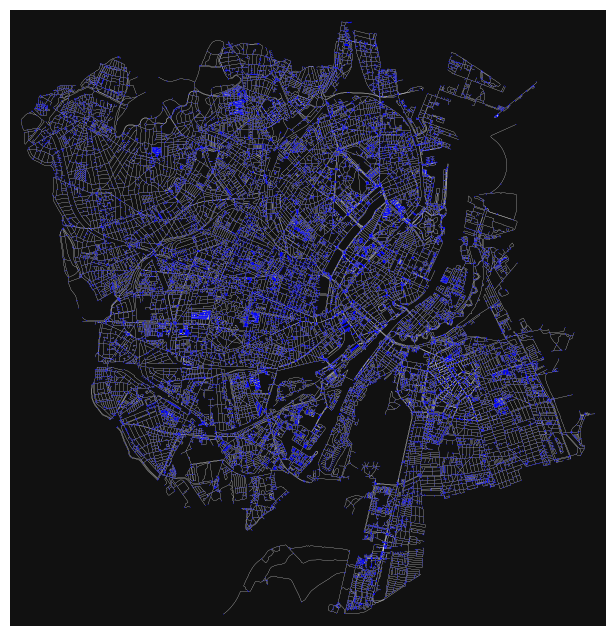

In [108]:
ox.plot_graph(G, node_size=0.3,node_color="b", edge_color="w", edge_linewidth=0.1);

In [109]:
G.number_of_nodes(), G.number_of_edges()

(47085, 130484)

In [110]:
list(G.edges)[:10]

[(118725, 1190873099, 0),
 (118725, 6357644352, 0),
 (118725, 2512504197, 0),
 (118738, 4924695592, 0),
 (118744, 1277939659, 0),
 (118744, 1277939659, 1),
 (118744, 1277939654, 0),
 (118744, 4924695593, 0),
 (118759, 12926452516, 0),
 (118759, 4815487352, 0)]

In [111]:
G.graph['crs']

'epsg:4326'

In [112]:
### Convert the crs of G to match the crs of copen
# G = ox.project_graph(G, to_crs=CRS)
# G.graph['crs']

## Voting Areas

This data is availible at: https://dataforsyningen.dk/data/4839

But we are using the gpkg provided in the lecture

In [86]:
df_voting_areas_denmark = gpd.read_file("../data/voting_areas.gpkg")
print(df_voting_areas_denmark.shape)
df_voting_areas_denmark.head()

(1347, 6)


,local_id,voting_name,municipal_id,area_name,ValgstedId,geometry
0,17,Hammerum-Gjellerup Hall'n,0657,Hammerum,657017,MULTIPOLYGON Z (((499898.900 6224849.820 0.000...
1,15,Gullestrup Sport og Kultur,0657,Gullestrup,657015,MULTIPOLYGON Z (((496037.860 6226101.190 0.000...
2,08,Sdr. Felding Hallen,0657,Sdr. Felding,657008,MULTIPOLYGON Z (((483026.180 6200592.380 0.000...
3,27,Vildbjerg Sports- og Kulturcenter,0657,Vildbjerg,657027,MULTIPOLYGON Z (((477917.280 6229128.160 0.000...
4,08,Længen,0210,Karlebo,210008,MULTIPOLYGON Z (((710547.580 6203125.960 0.000...


In [87]:
voting_areas = df_voting_areas_denmark[df_voting_areas_denmark.municipal_id.isin(["0101", "0147"])]
print(voting_areas.shape)
voting_areas.head()

(61, 6)


,local_id,voting_name,municipal_id,area_name,ValgstedId,geometry
205,55,Skolen i Sydhavnen,0101,9. Sydhavn,101055,MULTIPOLYGON Z (((723500.570 6172060.110 0.000...
206,13,Hal C,0101,3. Syd,101013,MULTIPOLYGON Z (((728020.400 6178372.760 0.000...
207,19,Skolen ved Sundet,0101,4. Øst,101019,MULTIPOLYGON Z (((729526.170 6172925.390 0.000...
437,53,Vesterbro Ny Skole,0101,9. Vest,101053,MULTIPOLYGON Z (((722991.140 6175150.160 0.000...
463,47,Sankt Annæ Gymnasium,0101,8. Sydøst,101047,MULTIPOLYGON Z (((721960.120 6174245.920 0.000...


<Axes: >

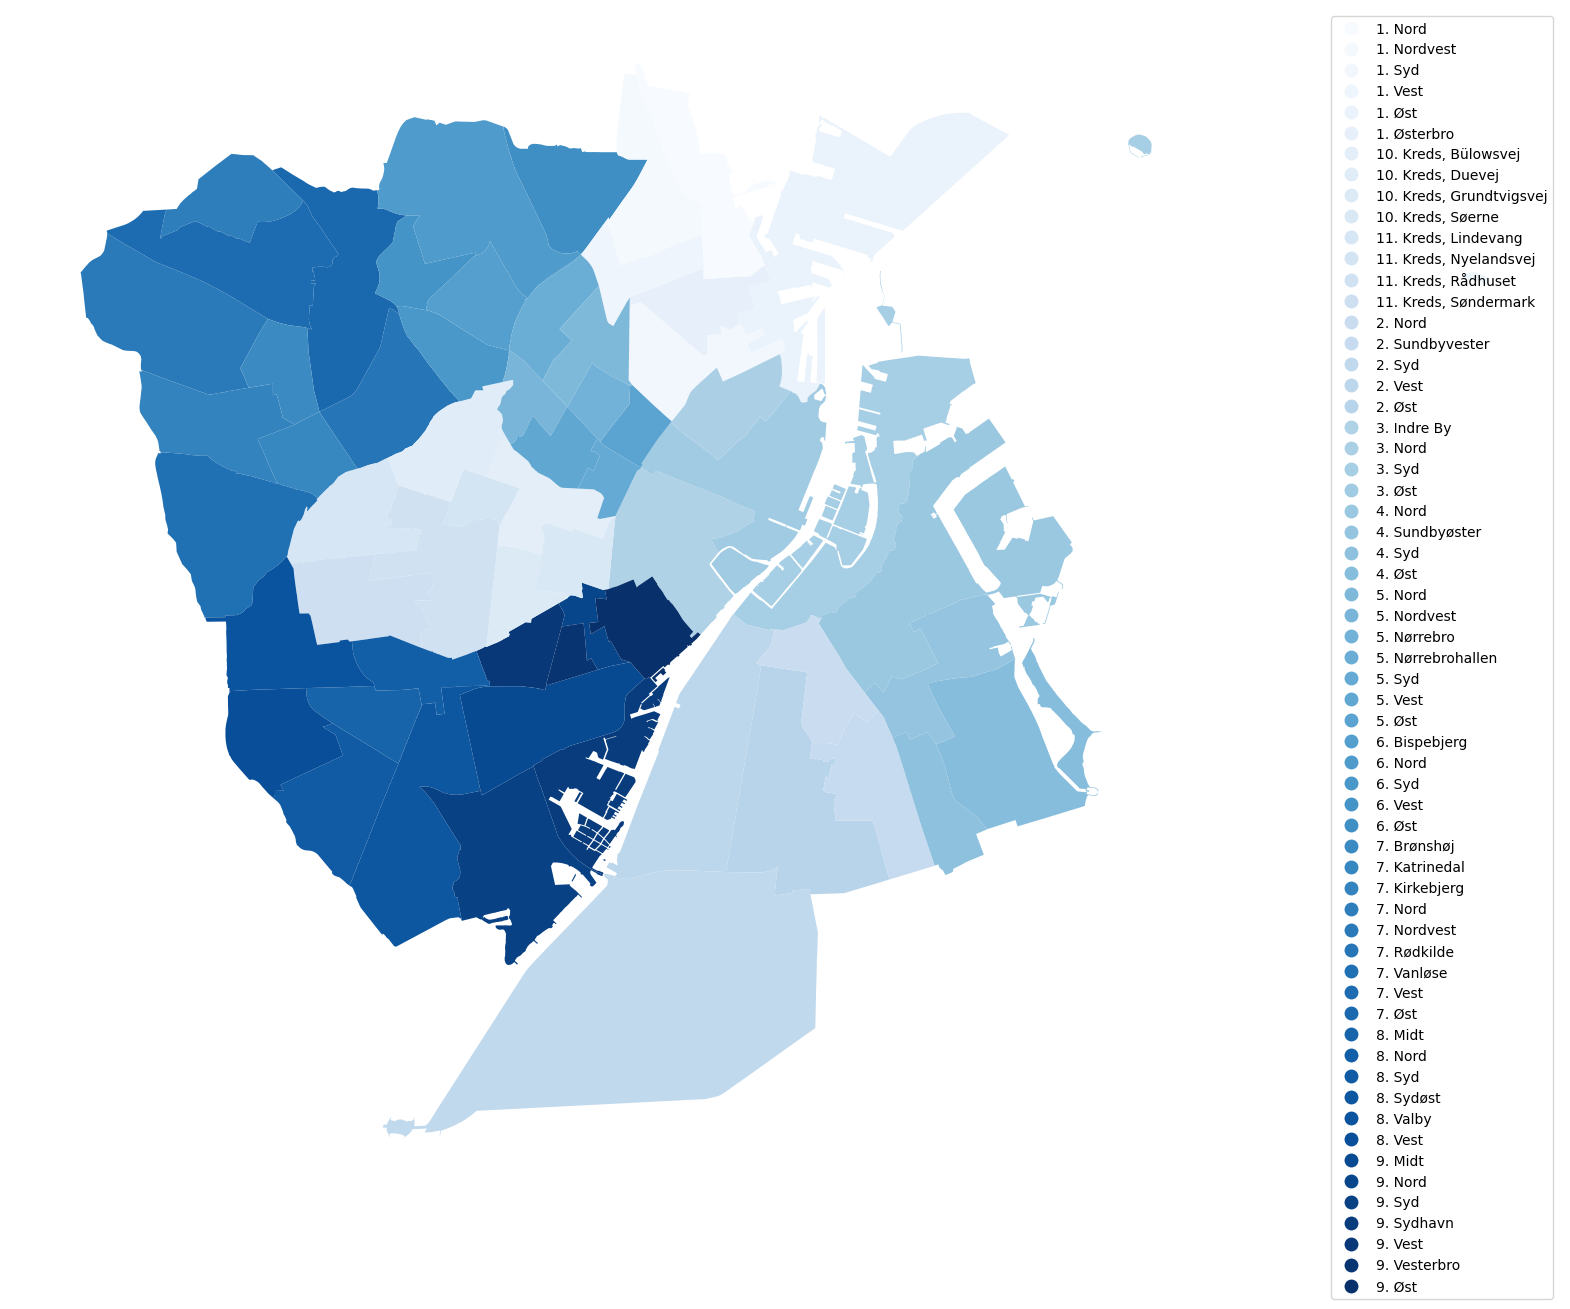

In [88]:
fig, ax = plt.subplots(figsize=(20,20))
ax.set_axis_off()
voting_areas.plot(ax=ax,categorical=True, column='area_name',cmap='Blues',legend=True)

## Air Quality <a id="air-quality"></a>

In [3]:
PATH_air = "../data/CAV_25May2021.geojson"

df_air = gpd.read_file(PATH_air)
print(f"Shape of df_air: {df_air.shape}")
df_air.head()

Cannot find header.dxf (GDAL_DATA is not defined)


Shape of df_air: (32270, 7)


,FID,Shape_Leng,ROAD_FID,Mixed_NO2,Mixed_UFP,Mixed_BC,geometry
0,0,58.821698,1,-999999,-999999,-999999.0,"LINESTRING (12.57828 55.69392, 12.57752 55.69423)"
1,1,31.898519,2,10,18500,0.8,"LINESTRING (12.62463 55.63461, 12.62473 55.63433)"
2,2,36.276259,3,9,12800,0.8,"LINESTRING (12.58604 55.60184, 12.58595 55.602..."
3,3,40.416066,4,9,10700,0.7,"LINESTRING (12.58629 55.59317, 12.58569 55.59305)"
4,4,32.734397,5,13,14500,1.1,"LINESTRING (12.58135 55.59200, 12.58130 55.59171)"


<Axes: >

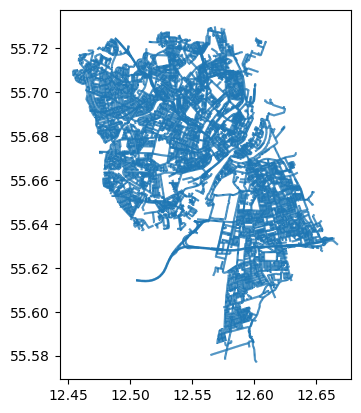

In [5]:
df_air.plot()

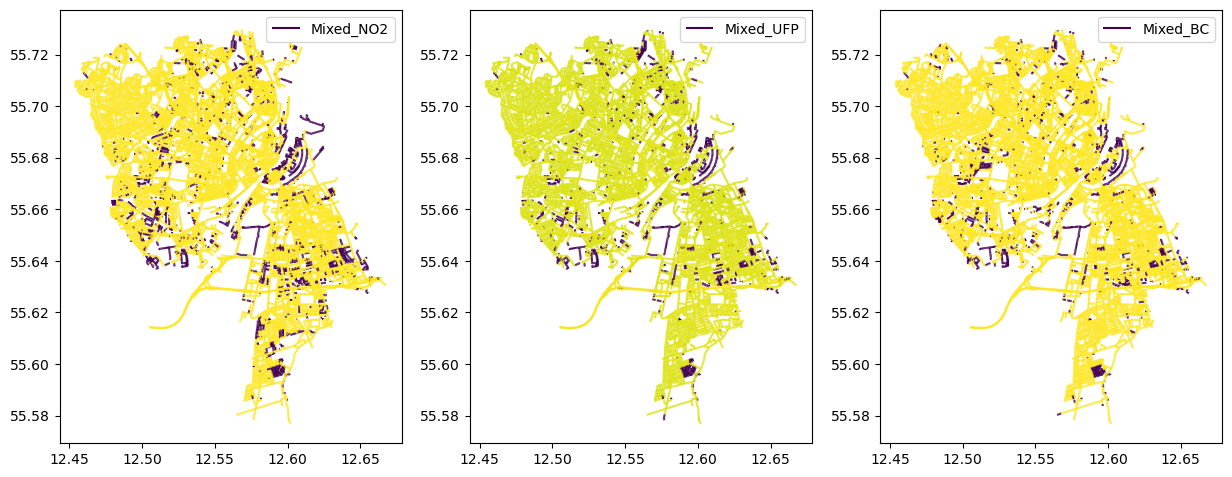

In [13]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 10))
columns_to_plot = ["Mixed_NO2", "Mixed_UFP", "Mixed_BC"]


for i, col in enumerate(columns_to_plot):
    df_air.plot(col, ax=axes[i], label=col)
    axes[i].legend()

In [14]:
df_air.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

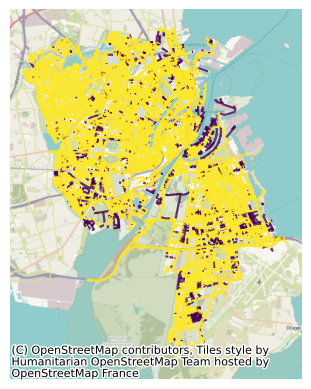

In [15]:
ax = df_air.plot("Mixed_NO2") #plot mixed NO2
ax.set_axis_off() #removing border axis
cx.add_basemap(ax, crs=df_air.crs); #providing a source for the image bellow the data
# contextily didn't understand the context of the data - we didn't provide a crs
# , source=cx.providers.CartoDB.Positron

## Green Areas <a id="green-areas"></a>


In [16]:
green_areas = ox.features_from_place(
    ["Copenhagen Municipality", "Frederiksberg Municipality"], tags={"leisure": "park", "landuse":["grass","cemerety","forest","meadow"]} 
    # tags={"leisure": "park", "landuse": "grass", "landuse": "cemetery", "landuse": "forest"}
)
green_areas.head()

source                   geometry created_by height  \
element_type osmid                                                             
node         12269322560    NaN  POINT (12.59942 55.68110)        NaN    NaN   
             12269322561    NaN  POINT (12.60022 55.68117)        NaN    NaN   
             12269322562    NaN  POINT (12.60091 55.68096)        NaN    NaN   
             12269322563    NaN  POINT (12.60034 55.68038)        NaN    NaN   
             12269322564    NaN  POINT (12.59957 55.68055)        NaN    NaN   

                         barrier  dog leaf_type natural opening_hours amenity  \
element_type osmid                                                              
node         12269322560     NaN  NaN       NaN     NaN           NaN     NaN   
             12269322561     NaN  NaN       NaN     NaN           NaN     NaN   
             12269322562     NaN  NaN       NaN     NaN           NaN     NaN   
             12269322563     NaN  NaN       NaN     NaN           NaN     NaN   
             12269322564     NaN  NaN       NaN     NaN           NaN     NaN   

                          ... fence_type survey:date loc_name area:highway  \
element_type osmid        ...                                                
node         12269322560  ...        NaN         NaN      NaN          NaN   
             12269322561  ...        NaN         NaN      NaN          NaN   
             12269322562  ...        NaN         NaN      NaN          NaN   
             12269322563  ...        NaN         NaN      NaN          NaN   
             12269322564  ...        NaN         NaN      NaN          NaN   

                         golf operator:wikidata operator:type area ways type  
element_type osmid                                                            
node         12269322560  NaN               NaN           NaN  NaN  NaN  NaN  
             12269322561  NaN               NaN           NaN  NaN  NaN  NaN  
             12269322562  NaN               NaN           NaN  NaN  NaN  NaN  
             12269322563  NaN               NaN           NaN  NaN  NaN  NaN  
             12269322564  NaN               NaN           NaN  NaN  NaN  NaN  

[5 rows x 62 columns]

In [17]:
green_areas.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

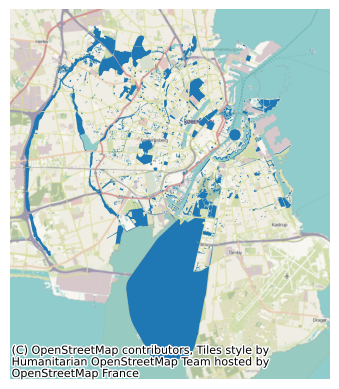

In [18]:
ax = green_areas.plot() 
ax.set_axis_off() #removing border axis
cx.add_basemap(ax, crs=green_areas.crs); #providing a source for the image bellow the data

In [ ]:
## TODO: remove polygons that are smaller than a given threshold, 
# probably we need to reproject into another crs  to get an accuate area



## Schools <a id="schools"></a>

In [44]:
df_schools = ox.features_from_place(
    ["Copenhagen Municipality", "Frederiksberg Municipality"], tags={"amenity": ["school", "kindergarden"]} 
)
print(df_schools.shape)
df_schools = df_schools.to_crs(CRS)
df_schools = df_schools[["name","amenity","geometry"]]
df_schools.head()

(169, 65)


name amenity  \
element_type osmid                                           
node         368383331       Skolen på Nyelandsvej  school   
             426949822  Trekronergade Freinetskole  school   
             584876286                 Niels Brock  school   
             836077987  Flyvevåbnets Officersskole  school   
             906940118                Krebs' Skole  school   

                                         geometry  
element_type osmid                                 
node         368383331  POINT (12.53033 55.68281)  
             426949822  POINT (12.51979 55.65721)  
             584876286  POINT (12.57459 55.68250)  
             836077987  POINT (12.57303 55.71747)  
             906940118  POINT (12.57571 55.68987)

### School - cleaning <a id="school-cleaning"></a>
Some school names appear more than once and all rows are a mix of points, linestrings, polygons and multipolygons. 

First, we find all schools that appear on multiple rows, and check if they are separate buildings. There are two instances of a school having overlapping representations (a point within a polygon), and in those cases we remove the polygon row.

Second, we define for all rows a center_point column, so all schools have the datatype: point. The center_point column is set as the geometry and the ond column is removed.

In [45]:
df_schools['name'].nunique()

157

In [46]:
df_dub_schools = df_schools[df_schools.groupby(["name"])["name"].transform("count")>1]
df_dub_schools

name amenity  \
element_type osmid                                             
node         3404320588                    Engskolen  school   
             3777120309         Skolen ved Bülowsvej  school   
             10719240514                        NEXT  school   
             10722048055                        NEXT  school   
             10722325872                        NEXT  school   
way          95689734             Damhusengens Skole  school   
             143895144                   Frejaskolen  school   
             221226636         Tove Ditlevsens Skole  school   
             221226637         Tove Ditlevsens Skole  school   
             279949395                   Frejaskolen  school   
             396531643            Damhusengens Skole  school   
             696105972    Københavns Erhvervsakademi  school   
             696105973    Københavns Erhvervsakademi  school   
             696110275    Københavns Erhvervsakademi  school   
             796364592          Skolen ved Bülowsvej  school   
             1189093372                    Engskolen  school   

                                                                   geometry  
element_type osmid                                                           
node         3404320588                           POINT (12.54556 55.66830)  
             3777120309                           POINT (12.54490 55.68129)  
             10719240514                          POINT (12.54054 55.71845)  
             10722048055                          POINT (12.55459 55.68308)  
             10722325872                          POINT (12.56044 55.70495)  
way          95689734     POLYGON ((12.47939 55.68643, 12.47947 55.68622...  
             143895144    POLYGON ((12.51513 55.66496, 12.51543 55.66483...  
             221226636    POLYGON ((12.54493 55.66603, 12.54576 55.66592...  
             221226637    POLYGON ((12.54742 55.66964, 12.54725 55.66963...  
             279949395    POLYGON ((12.51344 55.66516, 12.51364 55.66511...  
             396531643    POLYGON ((12.48077 55.68580, 12.48061 55.68577...  
             696105972    POLYGON ((12.53676 55.70422, 12.53669 55.70420...  
             696105973    POLYGON ((12.53864 55.70660, 12.53915 55.70656...  
             696110275    POLYGON ((12.55153 55.69518, 12.55136 55.69516...  
             796364592    POLYGON ((12.54533 55.68264, 12.54572 55.68254...  
             1189093372   POLYGON ((12.54479 55.66815, 12.54537 55.66804...

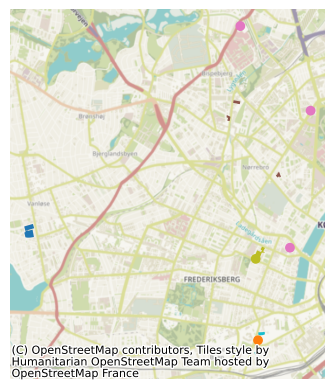

In [47]:
ax = df_dub_schools.plot("name") 
ax.set_axis_off() #removing border axis
cx.add_basemap(ax, crs=df_dub_schools.crs); #providing a source for the image bellow the data

c:\Users\mespi\Desktop\GeoSpatial_DS\.pixi\envs\default\lib\site-packages\contextily\tile.py:645: UserWarning: The inferred zoom level of 20 is not valid for the current tile provider (valid zooms: 0 - 19).
  warnings.warn(msg)


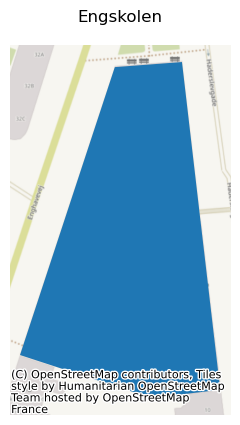

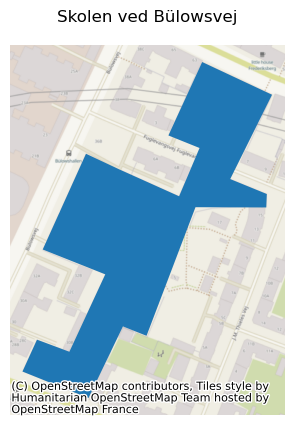

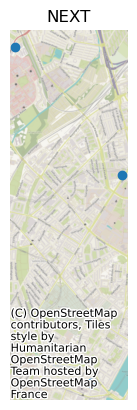

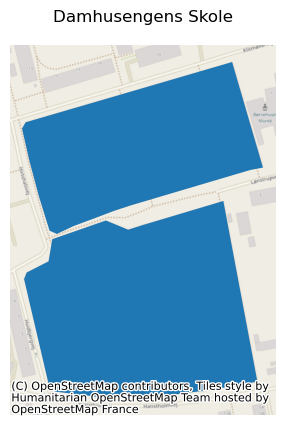

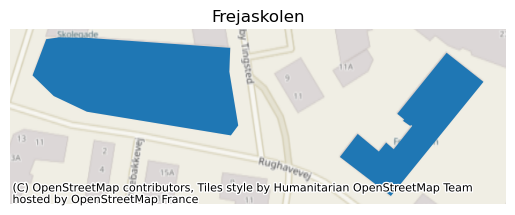

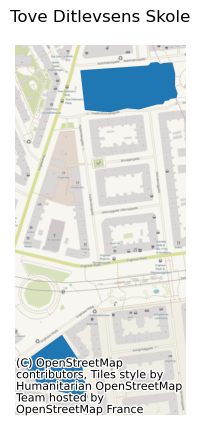

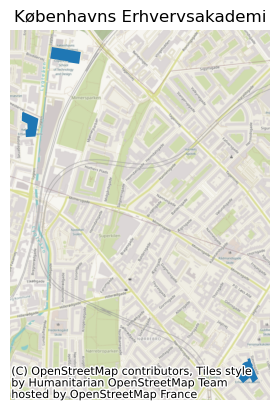

In [48]:
name_dub = df_dub_schools['name'].unique()
for name in name_dub:
    df_dub_school_nex = df_dub_schools[df_dub_schools['name']==name]
    ax = df_dub_school_nex.plot() 
    ax.set_axis_off() #removing border axis
    ax.set_title(name)
    cx.add_basemap(ax, crs=df_dub_school_nex.crs);


In [49]:
df_dub_school_eng = df_dub_schools[df_dub_schools['name']=="Engskolen"]
df_dub_school_eng

,,name,amenity,geometry
element_type,osmid,,,
node,3404320588,Engskolen,school,POINT (12.54556 55.66830)
way,1189093372,Engskolen,school,"POLYGON ((12.54479 55.66815, 12.54537 55.66804..."


c:\Users\mespi\Desktop\GeoSpatial_DS\.pixi\envs\default\lib\site-packages\contextily\tile.py:645: UserWarning: The inferred zoom level of 20 is not valid for the current tile provider (valid zooms: 0 - 19).
  warnings.warn(msg)


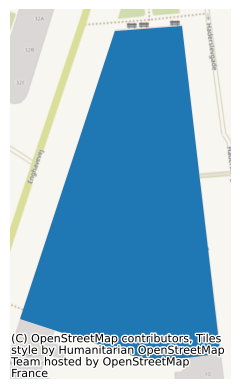

In [50]:
ax = df_dub_school_eng.plot() 
ax.set_axis_off() #removing border axis
cx.add_basemap(ax, crs=df_dub_school_eng.crs); #providing a source for the image bellow the data

In [51]:
df_schools.geom_type.unique()

array(['Point', 'Polygon', 'MultiPolygon'], dtype=object)

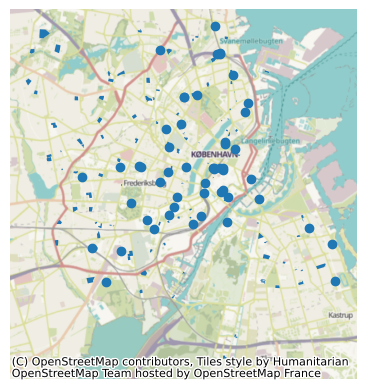

In [52]:
ax = df_schools.plot() 
ax.set_axis_off() #removing border axis
cx.add_basemap(ax, crs=df_schools.crs); #providing a source for the image bellow the data

In [54]:
index = df_schools.reset_index().index
df_schools["school_id"] = index
df_schools[df_schools['name']=="Engskolen"] # pol id = 158

,,name,amenity,geometry,school_id
element_type,osmid,,,,
node,3404320588,Engskolen,school,POINT (12.54556 55.66830),13
way,1189093372,Engskolen,school,"POLYGON ((12.54479 55.66815, 12.54537 55.66804...",158


In [55]:
df_schools[df_schools['name']=="Skolen ved Bülowsvej"] # pol id = 137

,,name,amenity,geometry,school_id
element_type,osmid,,,,
node,3777120309,Skolen ved Bülowsvej,school,POINT (12.54490 55.68129),17
way,796364592,Skolen ved Bülowsvej,school,"POLYGON ((12.54533 55.68264, 12.54572 55.68254...",137


In [56]:
# remove rows with polygons that are already represented with a point
df_schools_clean = df_schools.drop(df_schools[df_schools["school_id"] == 137].index)
df_schools_clean = df_schools_clean.drop(df_schools_clean[df_schools_clean["school_id"] == 158].index)

In [57]:
df_schools_clean

name amenity  \
element_type osmid                                            
node         368383331        Skolen på Nyelandsvej  school   
             426949822   Trekronergade Freinetskole  school   
             584876286                  Niels Brock  school   
             836077987   Flyvevåbnets Officersskole  school   
             906940118                 Krebs' Skole  school   
...                                             ...     ...   
way          1421539225   Den Classenske Legatskole  school   
relation     1614047                   Dyvekeskolen  school   
             8033590      Christianshavns Gymnasium  school   
             12671081                Guldberg Skole  school   
             12734639             Skolen ved Søerne  school   

                                                                  geometry  \
element_type osmid                                                           
node         368383331                           POINT (12.53033 55.68281)   
             426949822                           POINT (12.51979 55.65721)   
             584876286                           POINT (12.57459 55.68250)   
             836077987                           POINT (12.57303 55.71747)   
             906940118                           POINT (12.57571 55.68987)   
...                                                                    ...   
way          1421539225  POLYGON ((12.57550 55.67309, 12.57555 55.67307...   
relation     1614047     POLYGON ((12.59488 55.64857, 12.59535 55.64851...   
             8033590     MULTIPOLYGON (((12.59474 55.67343, 12.59460 55...   
             12671081    MULTIPOLYGON (((12.55220 55.69657, 12.55238 55...   
             12734639    MULTIPOLYGON (((12.55249 55.67845, 12.55247 55...   

                         school_id  
element_type osmid                  
node         368383331           0  
             426949822           1  
             584876286           2  
             836077987           3  
             906940118           4  
...                            ...  
way          1421539225        164  
relation     1614047           165  
             8033590           166  
             12671081          167  
             12734639          168  

[167 rows x 4 columns]

In [ ]:
df_schools_clean["center_point"] = df_schools_clean.representative_point() # used instead of centroid() because this works if the centroid is not within the polygon
df_schools_clean

name amenity  \
element_type osmid                                            
node         368383331        Skolen på Nyelandsvej  school   
             426949822   Trekronergade Freinetskole  school   
             584876286                  Niels Brock  school   
             836077987   Flyvevåbnets Officersskole  school   
             906940118                 Krebs' Skole  school   
...                                             ...     ...   
way          1421539225   Den Classenske Legatskole  school   
relation     1614047                   Dyvekeskolen  school   
             8033590      Christianshavns Gymnasium  school   
             12671081                Guldberg Skole  school   
             12734639             Skolen ved Søerne  school   

                                                                  geometry  \
element_type osmid                                                           
node         368383331                           POINT (12.53033 55.68281)   
             426949822                           POINT (12.51979 55.65721)   
             584876286                           POINT (12.57459 55.68250)   
             836077987                           POINT (12.57303 55.71747)   
             906940118                           POINT (12.57571 55.68987)   
...                                                                    ...   
way          1421539225  POLYGON ((12.57550 55.67309, 12.57555 55.67307...   
relation     1614047     POLYGON ((12.59488 55.64857, 12.59535 55.64851...   
             8033590     MULTIPOLYGON (((12.59474 55.67343, 12.59460 55...   
             12671081    MULTIPOLYGON (((12.55220 55.69657, 12.55238 55...   
             12734639    MULTIPOLYGON (((12.55249 55.67845, 12.55247 55...   

                         school_id               center_point  
element_type osmid                                             
node         368383331           0  POINT (12.53033 55.68281)  
             426949822           1  POINT (12.51979 55.65721)  
             584876286           2  POINT (12.57459 55.68250)  
             836077987           3  POINT (12.57303 55.71747)  
             906940118           4  POINT (12.57571 55.68987)  
...                            ...                        ...  
way          1421539225        164  POINT (12.57558 55.67280)  
relation     1614047           165  POINT (12.59689 55.64815)  
             8033590           166  POINT (12.59526 55.67342)  
             12671081          167  POINT (12.55319 55.69316)  
             12734639          168  POINT (12.55276 55.67791)  

[167 rows x 5 columns]

In [59]:
# Make new version that does not have the original geometry column with polygons and multipolygons
df_schools_points = df_schools_clean[["center_point", "amenity", "name","school_id"]].copy()

# Make center_point the geometry used in the dataframe
df_schools_points = df_schools_points.set_geometry("center_point")

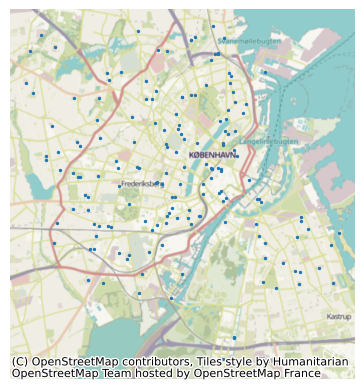

In [61]:
ax = df_schools_points.plot(markersize=2) 
ax.set_axis_off() #removing border axis
cx.add_basemap(ax, crs=df_schools_points.crs); #providing a source for the image bellow the data

## Hospitals and Clinics <a id="hospitals"></a>


In [63]:
df_hospital_clinic = ox.features_from_place(
    ["Copenhagen Municipality", "Frederiksberg Municipality"], tags={"amenity": ["clinic", "doctors", "hospital"]} 
)

# there are more tags under "healthcare", but those are very specific, and we would rather have the more general practitioners, clinics and hospitals
df_hospital_clinic.geom_type.unique()

array(['Point', 'Polygon'], dtype=object)

In [64]:
df_hospital_clinic.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
MultiIndex: 71 entries, ('node', 413546247) to ('way', 365563221)
Data columns (total 38 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   amenity                   71 non-null     object  
 1   wheelchair                13 non-null     object  
 2   geometry                  71 non-null     geometry
 3   branch                    2 non-null      object  
 4   check_date                9 non-null      object  
 5   healthcare                67 non-null     object  
 6   name                      67 non-null     object  
 7   opening_hours             11 non-null     object  
 8   operator                  5 non-null      object  
 9   phone                     19 non-null     object  
 10  website                   36 non-null     object  
 11  healthcare:speciality     17 non-null     object  
 12  emergency                 7 non-null      object  
 13  old_name  

In [66]:
df_hospital_clinic_cp = df_hospital_clinic[["geometry", "amenity", "name", "nodes"]].copy()
df_hospital_clinic_cp["center_point"] = df_hospital_clinic_cp.representative_point() 

# Make new version that does not have the original geometry column with polygons
df_hospital_clinic_points = df_hospital_clinic_cp[["center_point", "amenity", "name", "nodes"]].copy()

# Make center_point the geometry used in the dataframe
df_hospital_clinic_points = df_hospital_clinic_points.set_geometry("center_point")

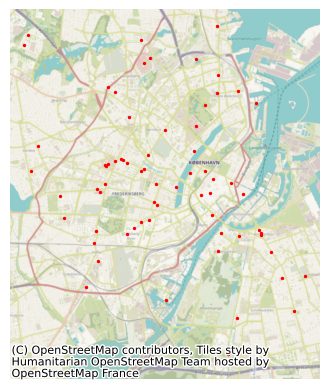

In [68]:
ax = df_hospital_clinic_points.plot(markersize=2, color='red') 
ax.set_axis_off() #removing border axis
cx.add_basemap(ax, crs=df_hospital_clinic_points.crs); #providing a source for the image bellow the data

# Create a network <a class="anchor" id="network"></a>

We will create a network using the street network data and adding the nodes from the ameneities (schools, hospitals and clinics, public transport) as nodes in the network.

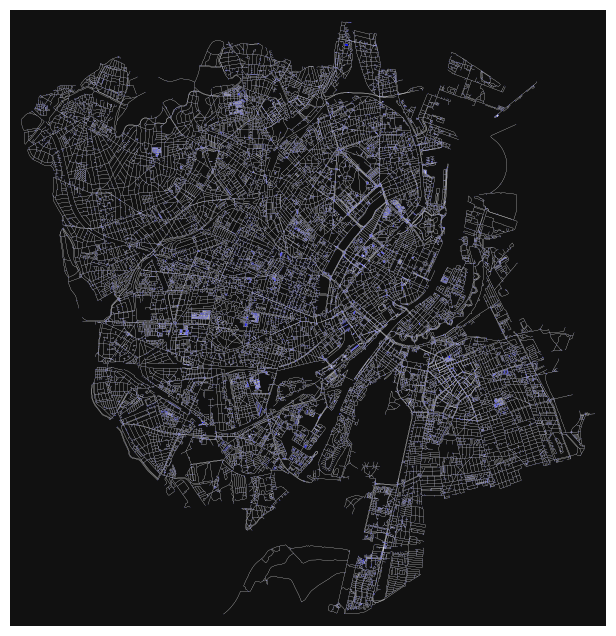

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [135]:
ox.plot_graph(G, node_size=0.05,node_color="b", edge_color="w", edge_linewidth=0.1)

In [144]:
df_schools_points

center_point amenity  \
element_type osmid                                           
node         368383331   POINT (12.53033 55.68281)  school   
             426949822   POINT (12.51979 55.65721)  school   
             584876286   POINT (12.57459 55.68250)  school   
             836077987   POINT (12.57303 55.71747)  school   
             906940118   POINT (12.57571 55.68987)  school   
...                                            ...     ...   
way          1421539225  POINT (12.57558 55.67280)  school   
relation     1614047     POINT (12.59689 55.64815)  school   
             8033590     POINT (12.59526 55.67342)  school   
             12671081    POINT (12.55319 55.69316)  school   
             12734639    POINT (12.55276 55.67791)  school   

                                               name  school_id  
element_type osmid                                              
node         368383331        Skolen på Nyelandsvej          0  
             426949822   Trekronergade Freinetskole          1  
             584876286                  Niels Brock          2  
             836077987   Flyvevåbnets Officersskole          3  
             906940118                 Krebs' Skole          4  
...                                             ...        ...  
way          1421539225   Den Classenske Legatskole        164  
relation     1614047                   Dyvekeskolen        165  
             8033590      Christianshavns Gymnasium        166  
             12671081                Guldberg Skole        167  
             12734639             Skolen ved Søerne        168  

[167 rows x 4 columns]

In [148]:
df_schools_points.geometry.type.unique()

array(['Point'], dtype=object)

In [152]:
df_nodes_school = df_schools_points[["school_id","center_point"]].copy()

df_nodes_school[['graph_node', 'distance_to_graph_node']] = df_nodes_school['center_point'].apply(
    lambda point: pd.Series(ox.nearest_nodes(G, point.x, point.y, return_dist=True))
)

In [153]:
df_nodes_school

school_id               center_point    graph_node  \
element_type osmid                                                            
node         368383331           0  POINT (12.53033 55.68281)  8.210390e+06   
             426949822           1  POINT (12.51979 55.65721)  2.090837e+07   
             584876286           2  POINT (12.57459 55.68250)  3.769760e+09   
             836077987           3  POINT (12.57303 55.71747)  2.961992e+08   
             906940118           4  POINT (12.57571 55.68987)  2.304187e+09   
...                            ...                        ...           ...   
way          1421539225        164  POINT (12.57558 55.67280)  1.419606e+09   
relation     1614047           165  POINT (12.59689 55.64815)  4.666408e+09   
             8033590           166  POINT (12.59526 55.67342)  8.099322e+06   
             12671081          167  POINT (12.55319 55.69316)  3.305197e+09   
             12734639          168  POINT (12.55276 55.67791)  1.640310e+09   

                         distance_to_graph_node  
element_type osmid                               
node         368383331                26.233550  
             426949822                33.352760  
             584876286                18.894592  
             836077987                89.639300  
             906940118                37.920333  
...                                         ...  
way          1421539225               29.510546  
relation     1614047                  63.684667  
             8033590                  44.665888  
             12671081                 13.277125  
             12734639                 18.985849  

[167 rows x 4 columns]

In [162]:
J = G.copy()
print(J.number_of_nodes(), J.number_of_edges())
J.add_nodes_from(df_nodes_school["graph_node"], attr_dict={"type": "schools"})
print(J.number_of_nodes(), J.number_of_edges())

47085 130484
47085 130484


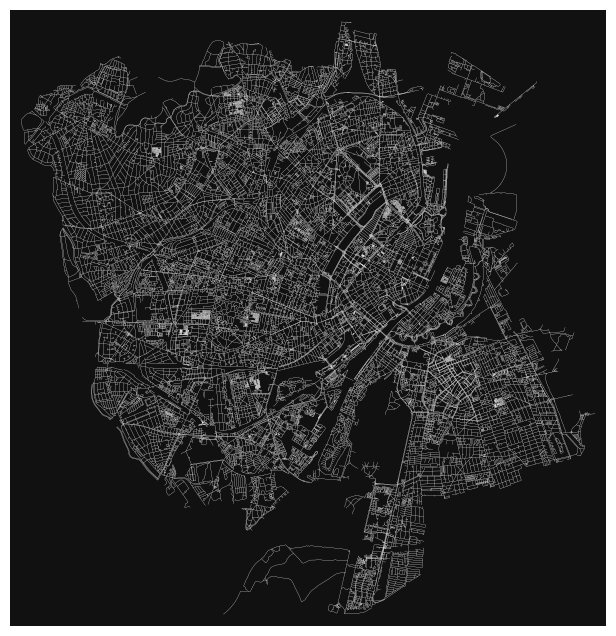

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [160]:
#plot the schools nodes in red and the rest of the graph in blue
node_colors = ['red' if J.nodes[node].get('type') == 'schools' else 'white' for node in J.nodes]
node_sizes = [10 if J.nodes[node].get('type') == 'schools' else 0 for node in J.nodes]
ox.plot_graph(J, node_size=node_sizes, node_color=node_colors, edge_color="w", edge_linewidth=0.1)

# Compute Distances 

The original point will be aech adress within the clean dataframe and the destination any of the features (school, medical services, green-areas)

In [76]:
## Start with a sample of 100 addresses to simplify the process
sample_addresses = address_gdf.sample(100, random_state=42)

In [104]:
## Target variable: walkeable distance between two points
def shortest_distance_network_route(start, target, G):
    #based on network distance 
    start_node, dis_start = ox.nearest_nodes(G, start.x, start.y, return_dist=True)
    target_node, dis_target = ox.nearest_nodes(G, target.x, target.y, return_dist=True)
    graph_route_length = nx.shortest_path_length(G, start_node, target_node, weight='length')
    total_length = dis_start + graph_route_length + dis_target
    route = ox.shortest_path(G, start_node, target_node, weight='length')
    return route, total_length

def shortest_distance_network(start, target, G):
    #based on network distance 
    start_node, dis_start = ox.nearest_nodes(G, start.x, start.y, return_dist=True)
    target_node, dis_target = ox.nearest_nodes(G, target.x, target.y, return_dist=True)
    graph_route_length = nx.shortest_path_length(G, start_node, target_node, weight='length')
    total_length = dis_start + graph_route_length + dis_target
    return total_length

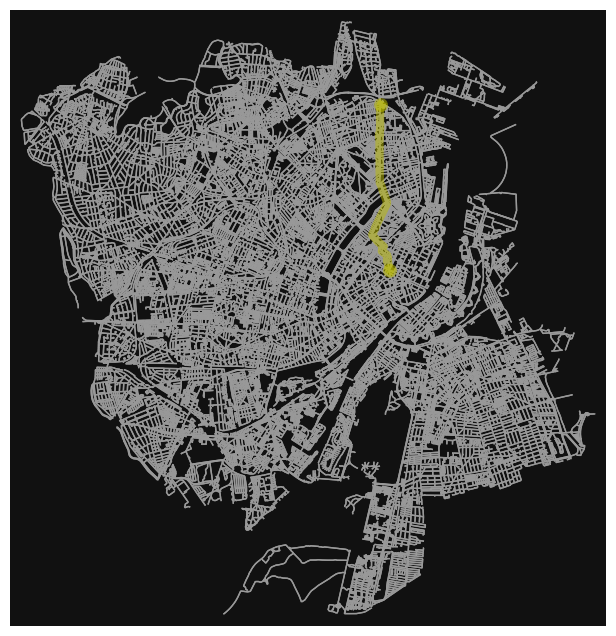

In [174]:
start = sample_addresses.geometry.iloc[0]
target = df_transport.geometry.iloc[0]

route, total_length = shortest_distance_network_route(start, target, G)
fig, ax = ox.plot_graph_route(G, route, route_color="y", route_linewidth=6, node_size=0)

This code is based on Lecture 10 and the concept of 15 min cities

## R-tree spatial index <a id="rtree"></a>

In [ ]:
## Euclidean distance based on https://geopandas.org/en/latest/docs/reference/api/geopandas.sjoin_nearest.html
adress_w_schools = gpd.sjoin_nearest(address_gdf[["id", "geometry"]], df_schools[["name", "geometry"]].rename(columns={"name": "school_name"}), how="left", distance_col="distance_to_school")

c:\Users\mespi\Desktop\GeoSpatial_DS\.pixi\envs\default\lib\site-packages\geopandas\array.py:365: UserWarning: Geometry is in a geographic CRS. Results from 'sjoin_nearest' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  warnings.warn(


In [119]:
max_dist = adress_w_schools.distance_to_school.max()
## get the farthest distance to a school for any address in the dataset
adress_w_schools[adress_w_schools['distance_to_school']==max_dist].iloc[0]

id                    eea75faf-c932-4269-afa7-bc8902955f67
geometry                   POINT (12.73078184 55.70352399)
index_right0                                           way
index_right1                                     403752277
school_name                      Naturcenter Amager Strand
distance_to_school                                0.101109
Name: 281794, dtype: object

POINT (12.73078184 55.70352399)
POINT (12.637960498434927 55.663177149999996)
18594.416423779698


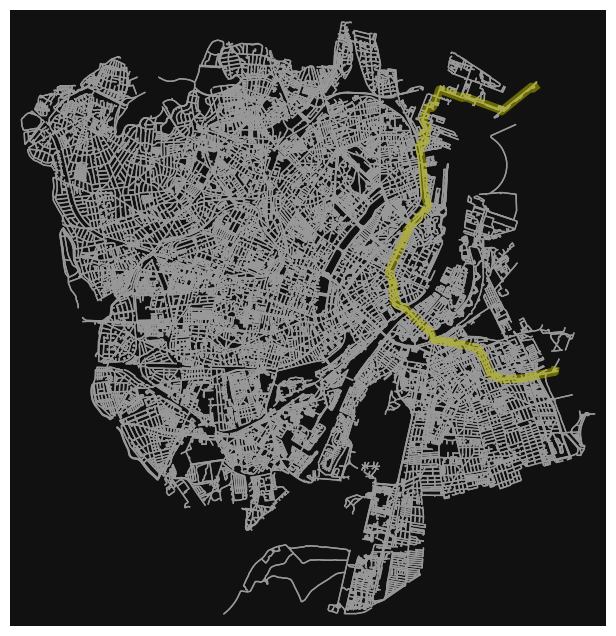

In [131]:
start = adress_w_schools[adress_w_schools['distance_to_school']==max_dist].geometry.iloc[0]
target =df_schools_points[df_schools_points['name']=="Naturcenter Amager Strand"].geometry.iloc[0]

print(start)
print(target)

route, total_length = shortest_distance_network_route(start, target, G)
print(total_length)
fig, ax = ox.plot_graph_route(G, route, route_color="y", route_linewidth=6, node_size=0, orig_dest_size=2)


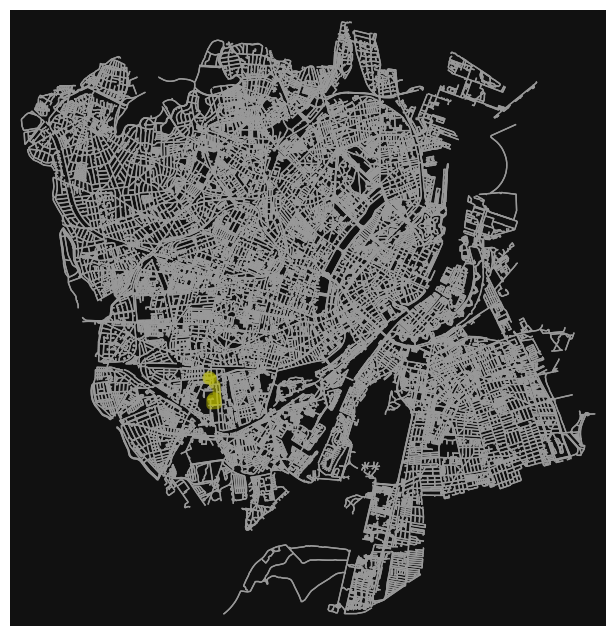

In [113]:
start = adress_w_schools.geometry.iloc[0]
target =df_schools[df_schools['name']=="Trekronergade Freinetskole"].geometry.iloc[0]

route, total_length = shortest_distance_network_route(start, target, G)
fig, ax = ox.plot_graph_route(G, route, route_color="y", route_linewidth=6, node_size=0)

## Tesselation

We will do a thesalation from every group of targets to determine what is the set of adresses whose closest point is each target. Then we will compute the distance bewteen the adress and the 

In [183]:
df_transport.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 1479 entries, 0 to 1478
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   name          1454 non-null   object  
 1   station_type  1476 non-null   object  
 2   geometry      1479 non-null   geometry
 3   transport_id  1479 non-null   int64   
dtypes: geometry(1), int64(1), object(2)
memory usage: 46.3+ KB


In [206]:
# change the poligons to points by taking the centroid of the poligons
df_transport['geometry'] = df_transport.geometry.centroid

C:\Users\mespi\AppData\Local\Temp\ipykernel_18924\3026775035.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  df_transport['geometry'] = df_transport.geometry.centroid


In [207]:
df_transport['closest_node'] = df_transport.geometry.apply(lambda x: ox.nearest_nodes(G, x.x, x.y))

In [209]:
df_transport.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 1479 entries, 0 to 1478
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   name          1454 non-null   object  
 1   station_type  1476 non-null   object  
 2   geometry      1479 non-null   geometry
 3   transport_id  1479 non-null   int64   
 4   closest_node  1479 non-null   int64   
dtypes: geometry(1), int64(2), object(2)
memory usage: 57.9+ KB


In [212]:
# safe transport data to not clean it again 
df_transport.to_csv("transport_data_cleaned.csv", index=False)

In [210]:
# do a tessellation of the city based on the transport stops and the network G
import momepy

tessellation = momepy.Tessellation(df_transport, G)
tessellation.head()



KeyError: "None of [Index([     118725,      118738,      118744,      118759,      118763,\n            118764,      118768,      118783,      118784,      118792,\n       ...\n       13772795184, 13772795186, 13772795187, 13772795188, 13772795191,\n       13772795194, 13772795195, 13772795198, 13774638648, 13774638654],\n      dtype='int64', length=47085)] are in the [columns]"